### Exploratory Data Analysis and Statistical Inference with the Boston Housing Dataset

In this project, I will work with a dataset containing information about real estate in Boston neighborhoods. The house_prices.csv file includes several characteristics of 506 Boston neighborhoods, described in detail below:


● CRIM: Per capita crime rate by neighborhood

● ZN: Proportion of residential land zoned for lots larger than 25,000 square feet

● INDUS: Proportion of non-retail business areas within the neighborhood

● CHAS: Charles River dummy variable (1 if the neighborhood borders the river, 0 otherwise)

● NOX: Nitrogen oxide concentration (parts per 10 million)

● RM: Average number of rooms per dwelling within the neighborhood

● AGE: Proportion of dwellings built before 1940 within the neighborhood

● DIS: Weighted distance of the neighborhood to five Boston employment centers

● RAD: Index of the neighborhood’s accessibility to radial highways

● TAX: Full-value property tax rate per $10,000 within the neighborhood

● PTRATIO: Pupil–teacher ratio within the neighborhood

● B: 1000 * (Bk - 0.63)^2, where Bk is the proportion of Black residents in the neighborhood. This transformed indicator measures the squared deviation of the White-to-Black population ratio from a reference value of 0.63

● LSTAT: Proportion of lower-status residents within the neighborhood population

● MEDV: Median value of homes in the neighborhood (in thousands of dollars)

In [1]:
#import the required libraries:

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm
from scipy.stats import t
from scipy.stats import chi2
from scipy.stats import f
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
file_path = folder / "ora11-hw3.csv"

print(file_path)
print(file_path.exists())

df_bost = pd.read_csv(file_path)

C:\Users\Balazs\OneDrive - elte.hu\Desktop\python_mat\11_óra\ora11-hw3.csv
True


In [12]:
#we load the data file:
df_bost = pd.read_csv("data/boston_housing.csv")

df_bost.head(50)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [13]:
df_bost.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


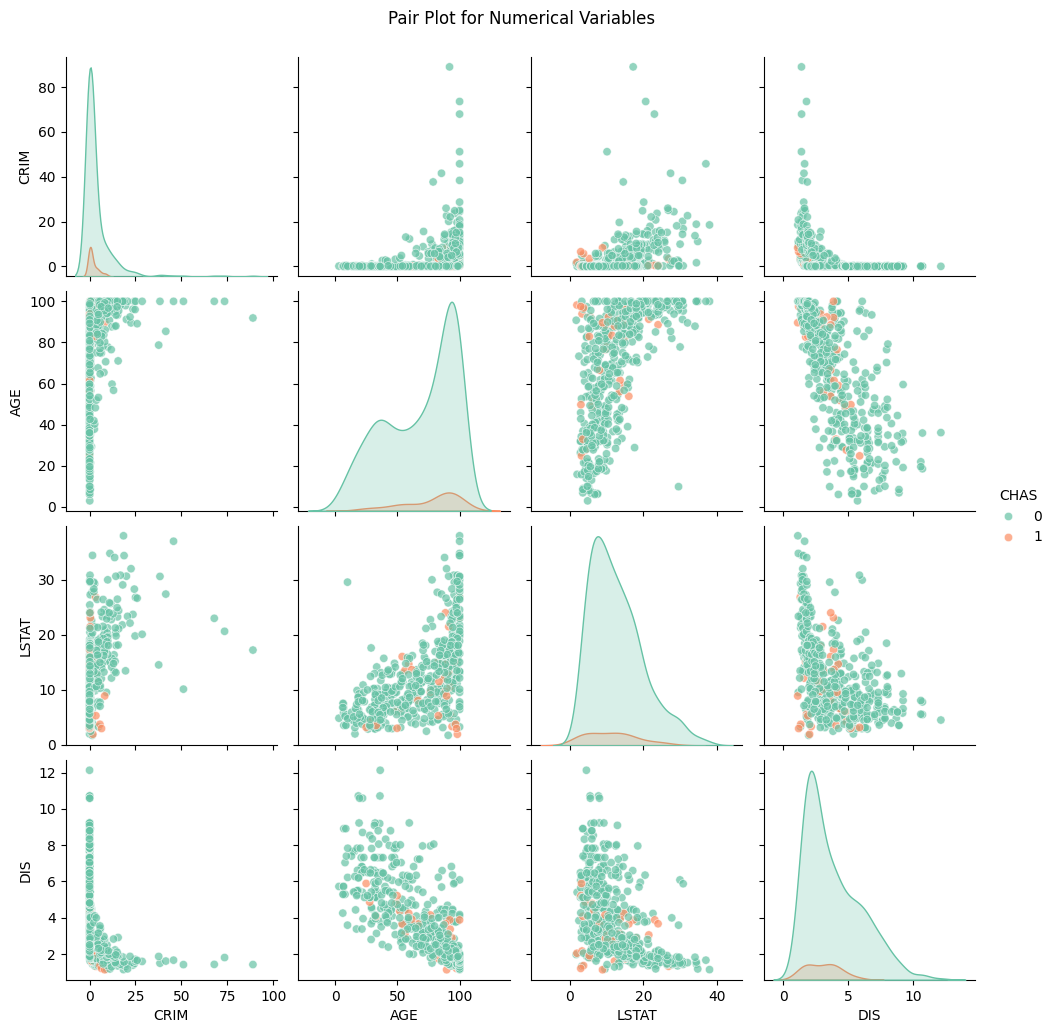

In [14]:
# A seaborn pairplot displays the relationships among multiple variables at once
# It creates a scatter plot for each pair of variables
# The colours indicate whether the neighborhood borders the Charles River
sns.pairplot(
    df_bost,
    vars=['CRIM', 'AGE', 'LSTAT', 'DIS'],
    hue='CHAS',
    palette='Set2',
    plot_kws={'alpha': 0.7}
)

# Adding a common title to the entire figure
# y=1.03 means that the title is positioned slightly higher,
# so that it does not overlap with the plots at the top
plt.suptitle('Pair Plot for Numerical Variables', y=1.03)

# Displaying the figure
plt.show()

The diagonal density plots show that the variables are not normally distributed. CRIM is strongly right-skewed: most neighborhoods have low crime rates, while a small number have extremely high values. LSTAT and DIS are also right-skewed, whereas AGE is concentrated toward higher values, indicating that many neighborhoods contain a large proportion of dwellings built before 1940. Among the relationships, a positive association between CRIM and LSTAT can be observed, suggesting that crime rates tend to increase as the proportion of lower-status residents rises. A negative relationship between CRIM and DIS is also visible: neighborhoods with higher crime rates tend to be located closer to Boston’s employment centers. Although this may seem counterintuitive from a European perspective, more affluent American suburban neighborhoods are often located farther from central urban areas. AGE and LSTAT are positively related, indicating that older neighborhoods generally have a higher proportion of lower-status residents. In contrast, the negative relationship between AGE and DIS suggests that older dwellings are more frequently located near the city center, while newer residential areas tend to be farther away. The colours represent the CHAS dummy variable: green observations correspond to neighborhoods that do not border the Charles River, while orange observations represent those that do. The two groups largely overlap, and the relatively small number of orange observations means that no clear separation between riverside and non-riverside neighborhoods can be identified from this visualization alone.

            Mean    Median  Standard deviation
CRIM    3.613524   0.25651            8.601545
AGE    68.574901  77.50000           28.148861
LSTAT  12.653063  11.36000            7.141062
DIS     3.795043   3.20745            2.105710


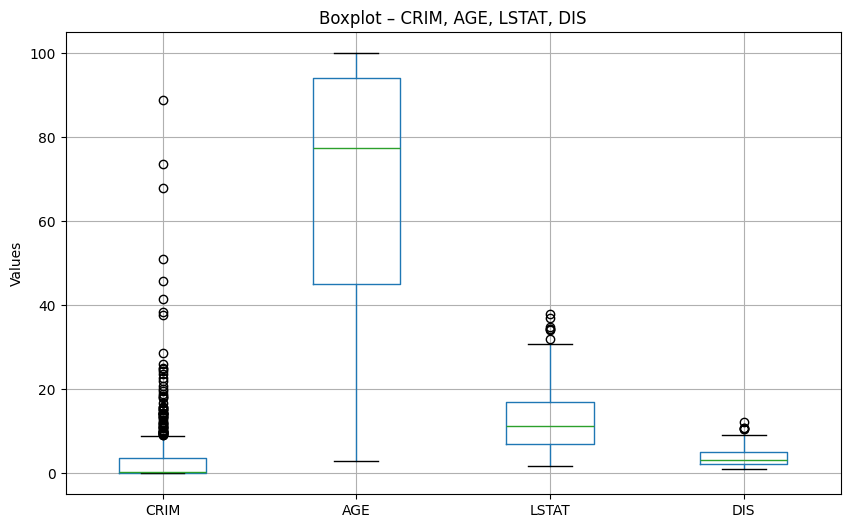

In [15]:
# selecting the examined variables from the dataset
cols = ['CRIM', 'AGE', 'LSTAT', 'DIS']
sub_df = df_bost[cols]


#creating a dataframe for the statistics
desc = pd.DataFrame({
    "Mean": sub_df.mean(),# calculating the mean for each variable
    "Median": sub_df.median(),# calculating the median
    "Standard deviation": sub_df.std()# calculating the standard deviation
})

#printing the results
print(desc)


# boxplot for all selected variables
plt.figure(figsize=(10,6))
sub_df.boxplot()


plt.title("Boxplot – CRIM, AGE, LSTAT, DIS")
plt.ylabel("Values")

# displaying the figure
plt.show()

The arithmetic mean is calculated as:

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

After arranging the observations in ascending order, the median is calculated as:

$$
\operatorname{Median}=
\begin{cases}
x_{\left(\frac{n+1}{2}\right)}, & \text{if } n \text{ is odd} \\[6pt]
\frac{x_{\left(\frac{n}{2}\right)}+x_{\left(\frac{n}{2}+1\right)}}{2}, & \text{if } n \text{ is even}
\end{cases}
$$

The sample standard deviation is calculated as:

$$
s=\sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

The distributions of the variables differ considerably. The **CRIM** variable is strongly right-skewed, as indicated by the large difference between its mean (3.61) and median (0.26), as well as by the numerous outliers visible in the box plot. In the case of **AGE**, the values are concentrated toward the upper end of the range, and the median (77.5) is higher than the mean, indicating slight left skewness. The **LSTAT** variable also shows a right-skewed distribution with several outliers. Here, it is again apparent that this variable moves to some extent together with **CRIM**. The **DIS** variable has a smaller standard deviation and a more balanced distribution with fewer outliers, indicating a more homogeneous spatial distribution.


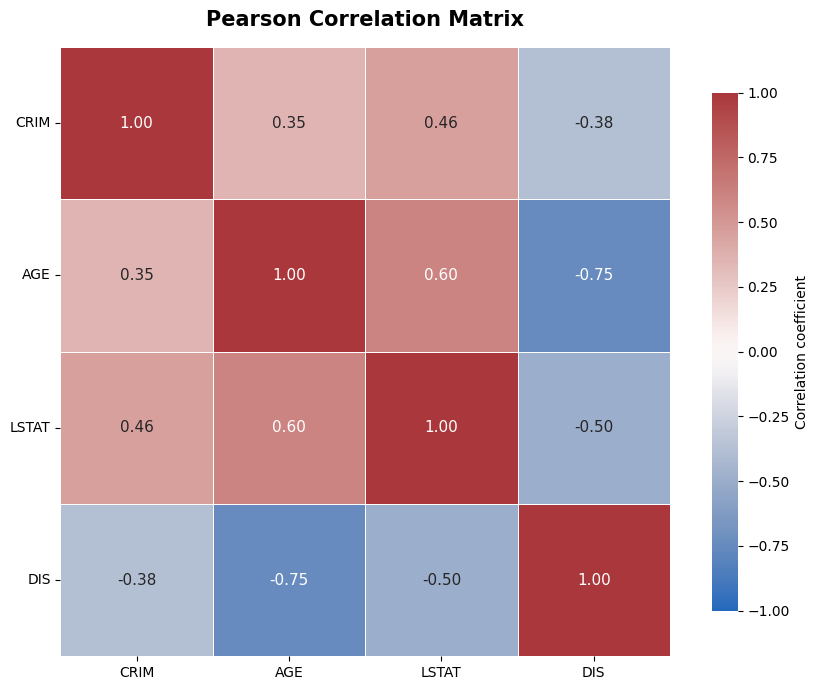

In [16]:
# creating the correlation matrix

#
# the .corr() function calculates all pairwise Pearson correlations
correlation_matrix = df_bost[['CRIM', 'AGE', 'LSTAT', 'DIS']].corr()

# creating the figure for the heatmap
plt.figure(figsize=(9, 7))

# the calculated correlation values
# annot=True → displays the correlation coefficients inside the cells
# fmt=".2f" → rounds the values to two decimal places
# cmap='vlag' → colour scale (blue = negative, red = positive correlation)
# center=0 → places zero at the centre of the colour scale
# linewidths → adds thin borders between the cells
# cbar_kws sets the label of the colour bar on the right
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.7,
    linecolor="white",
    annot_kws={"size": 11},
    cbar_kws={"label": "Correlation coefficient", "shrink": 0.85}
)

# graph title
plt.title("Pearson Correlation Matrix",
          fontsize=15,
          fontweight="bold",
          pad=15)

# setting the x-axis labels
# np.arange creates the axis positions
# +0.5 places the labels in the centre of the cells
# rotation=0 keeps the labels horizontal
plt.xticks(ticks=np.arange(len(correlation_matrix.columns)) + 0.5,
           labels=correlation_matrix.columns,
           rotation=0)

# setting the y-axis labels
# rotation=0 keeps the labels horizontal
plt.yticks(ticks=np.arange(len(correlation_matrix.index)) + 0.5,
           labels=correlation_matrix.index,
           rotation=0)

# adjusting the layout
plt.tight_layout()

# displaying the graph
plt.show()

The Pearson correlation coefficient measures the strength and direction of the linear relationship between two variables. It is calculated as:

$$
r_{xy}=
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
\sqrt{
\sum_{i=1}^{n}(x_i-\bar{x})^2
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
}
$$

where:

- $x_i$ and $y_i$ are the individual observations,
- $\bar{x}$ and $\bar{y}$ are the means of the two variables,
- $n$ is the number of observations.

The coefficient ranges from $-1$ to $+1$. A value close to $+1$ indicates a strong positive linear relationship, a value close to $-1$ indicates a strong negative linear relationship, and a value close to $0$ indicates little or no linear relationship.

A **moderate positive correlation (0.46) exists between CRIM and LSTAT**, which supports our earlier observations: a higher crime rate in a neighborhood is associated with a relatively higher proportion of lower-status residents in the same area. A **stronger positive relationship (0.60) can be observed between AGE and LSTAT**, meaning that older dwellings and neighborhoods tend to have a higher proportion of lower-status residents. The strongest relationship is visible **between AGE and DIS (-0.75)**, indicating a strong negative correlation: older housing stock tends to be located closer to the city center. A negative relationship (-0.50) can also be observed between LSTAT and DIS, meaning that lower-status residents tend to be concentrated closer to the employment centers. The negative relationship between CRIM and DIS (-0.38) is weaker, but it similarly indicates that higher crime rates are more characteristic of neighborhoods located closer to the employment centers.


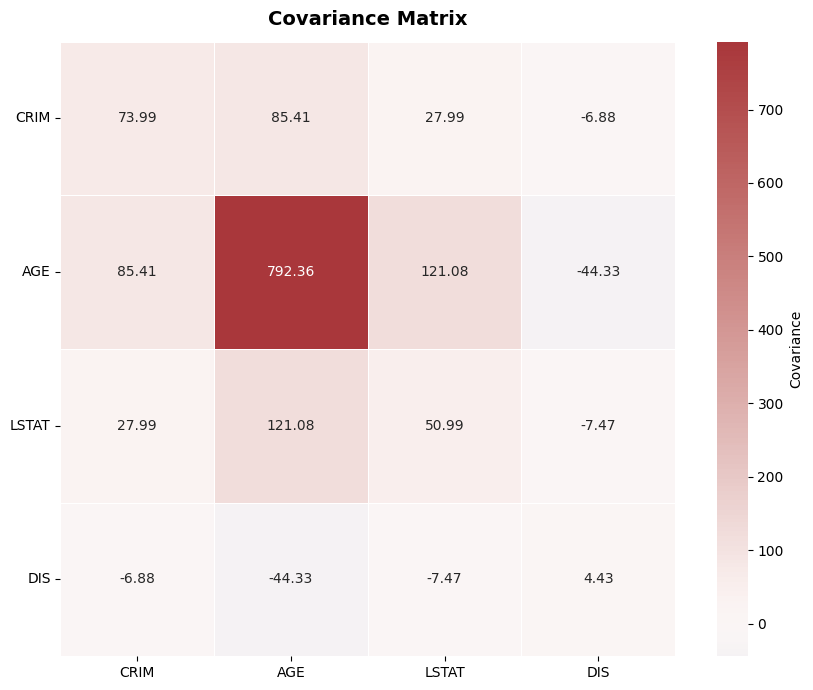

In [17]:
# selecting the variables for the analysis
cols = ['CRIM', 'AGE', 'LSTAT', 'DIS']
selected_df = df_bost[cols]

# calculating the covariance matrix
covariance_matrix = selected_df.cov()

# creating the figure for the covariance heatmap
plt.figure(figsize=(9, 7))

# covariance heatmap
sns.heatmap(
    covariance_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Covariance"}
)

# graph title
plt.title(
    "Covariance Matrix",
    fontsize=14,
    fontweight="bold",
    pad=12
)

# setting the axis labels
plt.xticks(rotation=0)
plt.yticks(rotation=0)

# adjusting and displaying the figure
plt.tight_layout()
plt.show()


Sample covariance measures whether two variables tend to change in the same or opposite directions. It is calculated as:

$$
s_{xy}=
\frac{1}{n-1}
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$$

A positive covariance indicates that the variables tend to increase together, while a negative covariance indicates that one variable tends to decrease as the other increases. However, its magnitude depends on the measurement scales of the variables.

The diagonal values represent the variances of the individual variables. AGE has the largest variance (792.36), indicating that the proportion of older dwellings differs considerably across the examined neighborhoods. In contrast, DIS has the smallest variance (4.43) and therefore shows less absolute dispersion on its original measurement scale. Among the variable pairs, CRIM and LSTAT have a positive covariance (27.99), meaning that neighborhoods with higher crime rates also tend to have higher proportions of lower-status residents. AGE and LSTAT also have a positive covariance (121.08), indicating that older neighborhoods tend to contain larger proportions of lower-status residents. The covariance between AGE and DIS is negative (-44.33), suggesting that neighborhoods with older housing stock tend to be closer to the employment centers. Negative covariances can also be observed between CRIM and DIS (-6.88) and between LSTAT and DIS (-7.47). Thus, neighborhoods farther from employment centers generally tend to have lower crime rates, smaller proportions of lower-status residents, and newer housing stock.

***For the mean proportion of dwellings built before 1940 in the neighborhoods (with an unknown population standard deviation)***


In [18]:
data_ki = df_bost['AGE'].dropna()#dropping missing values, if there are any

# calculating the confidence interval for the mean
konf = 0.95 # 95% confidence level
n = len(data_ki) # sample size
mean = np.mean(data_ki)# sample mean
stderr = np.std(data_ki, ddof=1) / np.sqrt(n)  # standard error

# t-distribution-based confidence interval due to the unknown population standard deviation
ki = stats.t.interval(konf, df=n-1, loc=mean, scale=stderr)
konf_int =konf*100

# Printing the results
print(f"Mean of the AGE variable: {mean:.4f}")
print(f"{konf_int:.1f}% confidence interval: ({ki[0]:.4f}, {ki[1]:.4f})")

Mean of the AGE variable: 68.5749
95.0% confidence interval: (66.1164, 71.0334)


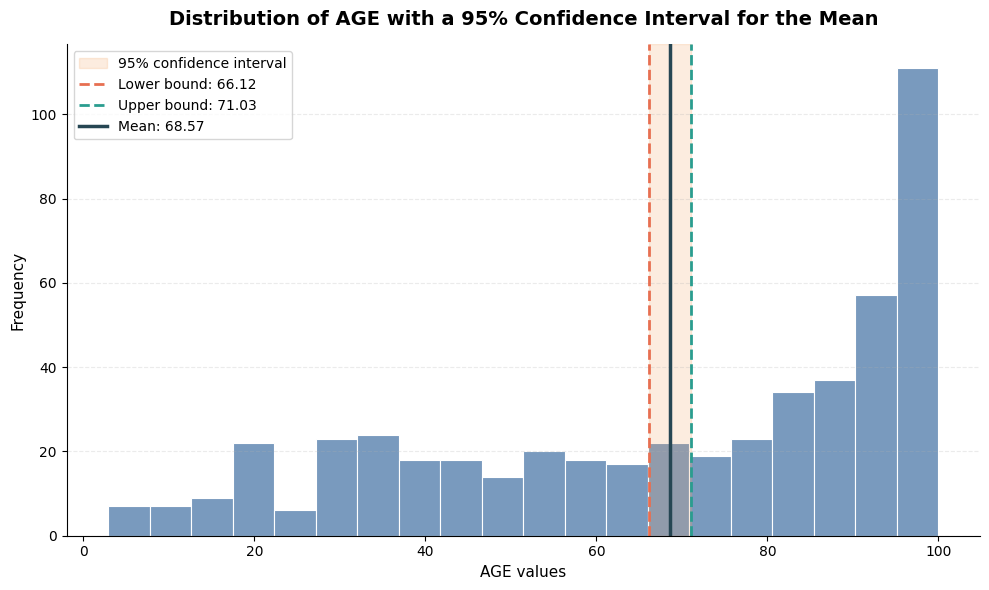

In [19]:
plt.figure(figsize=(10, 6))

# histogram showing the distribution of AGE
sns.histplot(
    data_ki,
    bins=20,
    color="#4C78A8",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8
)

# shaded area representing the confidence interval
plt.axvspan(
    ki[0],
    ki[1],
    color="#F4A261",
    alpha=0.20,
    label="95% confidence interval"
)

# lower bound of the confidence interval
plt.axvline(
    x=ki[0],
    color="#E76F51",
    linestyle="--",
    linewidth=2,
    label=f"Lower bound: {ki[0]:.2f}"
)

# upper bound of the confidence interval
plt.axvline(
    x=ki[1],
    color="#2A9D8F",
    linestyle="--",
    linewidth=2,
    label=f"Upper bound: {ki[1]:.2f}"
)

# sample mean
plt.axvline(
    x=mean,
    color="#264653",
    linewidth=2.5,
    label=f"Mean: {mean:.2f}"
)

plt.title(
    "Distribution of AGE with a 95% Confidence Interval for the Mean",
    fontsize=14,
    fontweight="bold",
    pad=14
)

plt.xlabel("AGE values", fontsize=11)
plt.ylabel("Frequency", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.legend(frameon=True, fontsize=10)
sns.despine()

plt.tight_layout()
plt.show()

The Student’s t-distribution is used because the population standard deviation is unknown and must be estimated from the sample. It accounts for the additional uncertainty introduced by using the sample standard deviation.

$$
CI_{95\%}=\bar{x}\pm t_{0.975;\,n-1}\frac{s}{\sqrt{n}}
$$


Here we can see the distribution of the AGE variable, together with its mean and the corresponding 95% confidence interval. The mean is approximately 68.6% (the proportion of dwellings built before 1940 within a neighborhood), and the confidence interval is relatively narrow (66–71%), indicating that the mean has been estimated with relatively high precision. The distribution is concentrated toward higher values, meaning that many neighborhoods have an above-average proportion of dwellings built before 1940.


***For the proportion of neighborhoods bordering the Charles River***


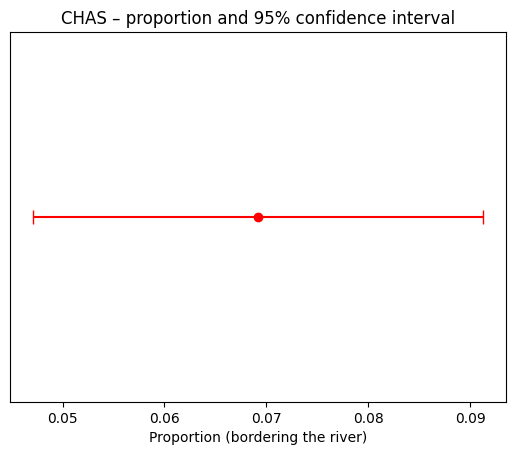

Estimated proportion: 6.917%
95% confidence interval: (0.047 - 0.091)


In [32]:
data = df_bost['CHAS'].dropna()

n = len(data)# sample size
sikeres = data.sum() # number of observations coded as 1 (neighborhoods bordering the river)

p_minta = sikeres / n# estimated proportion

konf = 0.95 # 95% confidence level

alpha = 1 - konf
# alpha is 5%: the probability that the interval does not contain the true value

z_ertek = stats.norm.ppf(1 - alpha/2)
# determining the critical z-value from the standard normal distribution
# the normal distribution is used because the sampling distribution is approximately normal for a large sample

hibahatar = z_ertek * np.sqrt(p_minta * (1 - p_minta) / n)
# Calculating the margin of error.
# it shows the amount of uncertainty around the estimated proportion
# Components of the formula:
# p_minta * (1 - p_minta) → binomial variance
# / n: a larger sample produces a smaller error

felso_hatar = p_minta - hibahatar # lower bound of the confidence interval: subtracting the margin of error from the estimated proportion
also_hatar = p_minta + hibahatar# upper bound of the confidence interval: adding the margin of error to the estimated proportion
becsult_arany = p_minta*100

plt.figure()

plt.errorbar(x=p_minta,color='red', y=1, xerr=hibahatar, fmt='o', capsize=5)

plt.title('CHAS – proportion and 95% confidence interval')
plt.xlabel('Proportion (bordering the river)')
plt.yticks([])

plt.show()
print(f"Estimated proportion: {becsult_arany:.3f}%")
print(f"95% confidence interval: ({felso_hatar:.3f} - {also_hatar:.3f})")

The proportion of neighborhoods bordering the Charles River is approximately 6.9% in the sample, meaning that a relatively small share of the examined neighborhoods is located directly beside the river.

The 95% confidence interval indicates that the true population proportion is likely to be between 4.7% and 9.1%. The interval is relatively narrow, suggesting that the estimate is reasonably precise.


***For the standard deviation of median property values across the neighborhoods***


Sample size of MEDV: 506.0000
Mean of MEDV: 22532.8063 dollars
Sample standard deviation of MEDV: 9197.1041 dollars
95% confidence interval for the standard deviation: (8663.2194 - 9801.6455 dollars)
95% confidence interval for chi-square: (444.6268 - 569.1608)


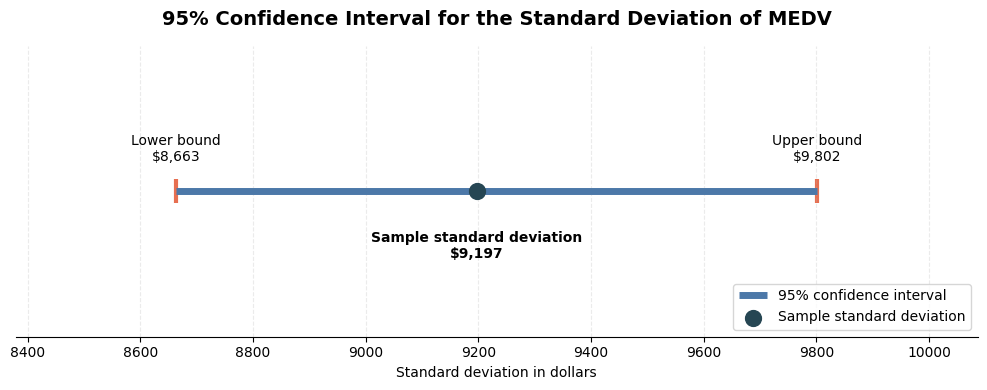

In [21]:
#MEDV is a continuous variable, so the estimate is based on the sample variance, and the confidence interval
#for the variance is based on the chi-square distribution

# selecting the variable
data_std = df_bost['MEDV'].dropna()


n = len(data_std) # sample size
s2 = np.var(data_std, ddof=1) # variance
s = np.std(data_std, ddof=1)# standard deviation

# Confidence level
konf = 0.95
alpha = 1 - konf

# Chi-square critical values
khi2_also = stats.chi2.ppf(alpha / 2, df=n - 1)
khi2_felso = stats.chi2.ppf(1 - alpha / 2, df=n - 1)

# Confidence interval for the variance
var_also = (n - 1) * s2 / khi2_felso
var_felso = (n - 1) * s2 / khi2_also

# Confidence interval for the standard deviation
std_also = np.sqrt(var_also)
std_felso = np.sqrt(var_felso)

# Printing the results
print(f"Sample size of MEDV: {n:.4f}")
print(f"Mean of MEDV: {data_std.mean()*1000:.4f} dollars")
print(f"Sample standard deviation of MEDV: {s*1000:.4f} dollars")
print(f"95% confidence interval for the standard deviation: ({std_also*1000:.4f} - {std_felso*1000:.4f} dollars)")
print(f"95% confidence interval for chi-square: ({khi2_also:.4f} - {khi2_felso:.4f})")
# converting the results to dollars for the visualization
std_point = s * 1000
ci_lower = std_also * 1000
ci_upper = std_felso * 1000

# creating the confidence interval plot
plt.figure(figsize=(10, 4))

# confidence interval
plt.hlines(
    y=0,
    xmin=ci_lower,
    xmax=ci_upper,
    color="#4C78A8",
    linewidth=5,
    label="95% confidence interval"
)

# confidence interval bounds
plt.scatter(
    [ci_lower, ci_upper],
    [0, 0],
    color="#E76F51",
    marker="|",
    s=300,
    linewidths=3
)

# sample standard deviation
plt.scatter(
    std_point,
    0,
    color="#264653",
    s=130,
    zorder=3,
    label="Sample standard deviation"
)

# adding value labels
plt.annotate(
    f"Lower bound\n${ci_lower:,.0f}",
    (ci_lower, 0),
    xytext=(0, 22),
    textcoords="offset points",
    ha="center"
)

plt.annotate(
    f"Sample standard deviation\n${std_point:,.0f}",
    (std_point, 0),
    xytext=(0, -48),
    textcoords="offset points",
    ha="center",
    fontweight="bold"
)

plt.annotate(
    f"Upper bound\n${ci_upper:,.0f}",
    (ci_upper, 0),
    xytext=(0, 22),
    textcoords="offset points",
    ha="center"
)

# formatting the figure
margin = (ci_upper - ci_lower) * 0.25
plt.xlim(ci_lower - margin, ci_upper + margin)
plt.ylim(-0.35, 0.35)
plt.yticks([])

plt.title(
    "95% Confidence Interval for the Standard Deviation of MEDV",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Standard deviation in dollars")
plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.legend(loc="lower right", frameon=True)
sns.despine(left=True)

plt.tight_layout()
plt.show()

The chi-square distribution is used because the population variance of MEDV is unknown and must be estimated from the sample variance. Assuming that MEDV is normally distributed, the statistic below follows a chi-square distribution with \(n-1\) degrees of freedom, allowing us to calculate a confidence interval for the population standard deviation.




hhi-square distribution or the population standard deviation:

$$
CI_{\sigma}=
\left(
\sqrt{\frac{(n-1)s^2}{\chi^2_{1-\alpha/2;\,n-1}}},
\sqrt{\frac{(n-1)s^2}{\chi^2_{\alpha/2;\,n-1}}}
\right)
$$


Based on the results, the average median property value across the neighborhoods is approximately 22,533. The sample standard deviation is 9,197, indicating substantial dispersion and considerable differences in property values between neighborhoods.

The 95% confidence interval for the standard deviation ranges from approximately $8,663 to $9,802. The interval is relatively narrow, suggesting a stable estimate, while also confirming that the variability in property values is not negligible.


***Interval Estimation at 1%, 5%, and 10% Significance Levels***

***The point estimates above are supplemented with interval estimates at each significance level, followed by a detailed interpretation of one selected interval.***

In [23]:
alphas = [0.01, 0.05, 0.10] # defining the significance levels to be examined (99%, 95%, 90%)

In [24]:
#interval estimation for the mean of AGE
# Here we calculate confidence intervals for the mean proportion of dwellings built before 1940
# because the population standard deviation is unknown, we use the t-distribution


# selecting the variable from the dataset
df_age = df_bost['AGE']


n_age = len(df_age)# sample size

mean_age = df_age.mean()# sample mean

std_age = df_age.std(ddof=1)# sample standard deviation: ddof=1 applies the corrected sample calculation

se_age = std_age / np.sqrt(n_age)# the standard error shows how much the sample mean may vary around the true population mean

print("Interval estimation for the mean of AGE")

# iterating through the three alpha levels using a for loop
for alpha in alphas:
    kon_szint = 1 - alpha# the confidence level is the complement of the significance level: for example, alpha=0.05 corresponds to 95% confidence

    t_prob = stats.t.ppf(1 - alpha/2, df=n_age - 1)
    # calculating the critical t-value for a two-sided interval
    # df=n_age-1: degrees of freedom

    also = mean_age - t_prob * se_age# lower bound of the confidence interval

    felso = mean_age + t_prob * se_age# upper bound of the confidence interval

    print(f"{int(kon_szint*100)}% confidence interval: ({also:.4f} - {felso:.4f})")
    # printing the interval corresponding to the current confidence level

Interval estimation for the mean of AGE
99% confidence interval: (65.3394 - 71.8104)
95% confidence interval: (66.1164 - 71.0334)
90% confidence interval: (66.5128 - 70.6370)


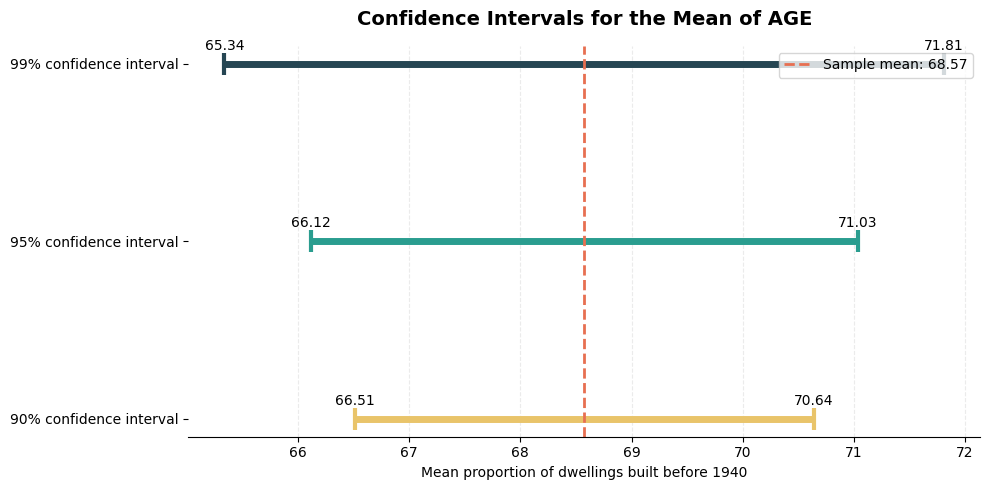

In [25]:
# calculating and storing the confidence intervals for visualization
age_intervals = []

for alpha in alphas:
    confidence_level = int((1 - alpha) * 100)
    t_critical = stats.t.ppf(1 - alpha/2, df=n_age - 1)

    lower_bound = mean_age - t_critical * se_age
    upper_bound = mean_age + t_critical * se_age

    age_intervals.append(
        (confidence_level, lower_bound, upper_bound)
    )

# colours for the different confidence levels
colors = ["#264653", "#2A9D8F", "#E9C46A"]

# creating the visualization
plt.figure(figsize=(10, 5))

for position, (level, lower, upper) in enumerate(age_intervals):

    # confidence interval
    plt.hlines(
        y=position,
        xmin=lower,
        xmax=upper,
        color=colors[position],
        linewidth=5
    )

    # lower and upper bounds
    plt.scatter(
        [lower, upper],
        [position, position],
        color=colors[position],
        marker="|",
        s=250,
        linewidths=3
    )

    # interval labels
    plt.annotate(
        f"{lower:.2f}",
        (lower, position),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

    plt.annotate(
        f"{upper:.2f}",
        (upper, position),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

# sample mean
plt.axvline(
    mean_age,
    color="#E76F51",
    linestyle="--",
    linewidth=2,
    label=f"Sample mean: {mean_age:.2f}"
)

# formatting the figure
plt.yticks(
    range(len(age_intervals)),
    [f"{level}% confidence interval" for level, _, _ in age_intervals]
)

plt.gca().invert_yaxis()

plt.title(
    "Confidence Intervals for the Mean of AGE",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Mean proportion of dwellings built before 1940")
plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.legend(frameon=True)
sns.despine(left=True)

plt.tight_layout()
plt.show()

The confidence intervals calculated for the mean of AGE show the ranges within which the true population mean may lie at different confidence levels. The 95% confidence interval estimates that the population mean proportion of dwellings built before 1940 lies between 66.12% and 71.03%.

Notably, the interval becomes wider as the confidence level increases: the 99% interval is the widest, while the 90% interval is the narrowest. This illustrates the trade-off between confidence and precision—the greater the certainty required when estimating the true parameter, the wider the corresponding interval must be.


In [26]:
#here we estimate the proportion of neighborhoods bordering the Charles River

# Selecting the CHAS variable
chas = df_bost['CHAS'].dropna()

# Calculating the basic values
n_chas = len(chas)
# The sample size

siker = chas.sum()
# The number of observations coded as 1
# Since CHAS is a dummy variable:
# 1 -> borders the river
# 0 -> does not border the river
# The sum therefore gives the number of "successful" cases

p_hat = siker / n_chas
# The estimated proportion (sample proportion)

print("\n Interval estimation for the proportion of CHAS=1")

# Iterating through the three alpha levels
for alpha in alphas:
    kon_szint = 1 - alpha
    # Confidence level

    z_crit = stats.norm.ppf(1 - alpha/2)
    # Critical z-value from the standard normal distribution
    # alpha/2 is used because this is a two-sided interval

    szelso = z_crit * np.sqrt(p_hat * (1 - p_hat) / n_chas) # calculating the margin of error for the proportion
    # components of the formula: p_hat * (1 - p_hat) -> binomial variance
    # / n_chas -> adjustment for the sample size
    # sqrt -> standard error
    # z_crit -> multiplier corresponding to the confidence level

    lower = p_hat - szelso
    # Lower bound

    upper = p_hat + szelso
    # Upper bound

    print(f"{int(kon_szint*100)}% confidence interval: ({lower:.4f}, {upper:.4f})")
    # Printing the confidence interval for the proportion


 Interval estimation for the proportion of CHAS=1
99% confidence interval: (0.0401, 0.0982)
95% confidence interval: (0.0471, 0.0913)
90% confidence interval: (0.0506, 0.0877)


In [27]:
# Selecting the MEDV variable
medv = df_bost['MEDV'].dropna()

# Calculating the basic statistics
n_medv = len(medv)
# sample size

s2_medv = medv.var(ddof=1)
# variance

s_medv = medv.std(ddof=1)
# standard deviation

print("\n Interval estimation for the standard deviation of MEDV")

#iterating through the three alpha levels
for alpha in alphas:
    kon_szint = 1 - alpha
    # confidence level

    chi2_also = stats.chi2.ppf(alpha/2, df=n_medv - 1)
    # lower chi-square value

    chi2_felso = stats.chi2.ppf(1 - alpha/2, df=n_medv - 1)
    # upper chi-square value

#since the chi-square values appear in the denominator, the lower and upper bounds are calculated in "reverse" order
    var_also = (n_medv - 1) * s2_medv / chi2_felso
    # lower bound of the variance interval

    var_felso = (n_medv - 1) * s2_medv / chi2_also
    # upper bound of the variance interval

    std_also = np.sqrt(var_also)
    # lower bound of the standard deviation interval

    std_felso = np.sqrt(var_felso)
    # upper bound of the standard deviation interval

    print(f"{int(kon_szint*100)}% confidence interval: ({std_also:.4f}, {std_felso:.4f})")


 Interval estimation for the standard deviation of MEDV
99% confidence interval: (8.5044, 10.0031)
95% confidence interval: (8.6632, 9.8016)
90% confidence interval: (8.7464, 9.7011)


The analysis examines whether the mean of the transformed variable related to the proportion of Black residents is equal in neighborhoods that border the Charles River

In [28]:
# selecting two groups from the data: neighborhoods bordering the Charles River and neighborhoods not bordering the river
# calculating the mean of the B variable in both groups
# h0: the means of the two groups are equal
# h1: the means of the two groups are different
# conducting a two-sample t-test because the population standard deviations are unknown
#this is a two-sided hypothesis test because we examine any difference, not only whether one mean is higher or lower


#defining the two groups

chas_1 = df_bost[df_bost['CHAS'] == 1]
chas_0 = df_bost[df_bost['CHAS'] == 0]

atlag_chas_1 = np.mean(chas_1['B'])
atlag_chas_0 = np.mean(chas_0['B'])
#calculating the mean of the B variable in both groups


#two-sample t-test

t_stat, p_ertek = ttest_ind( # returning the t-statistic and p-value
    chas_1['B'],
    chas_0['B'],
    equal_var=True
)
# ttest_ind(...) = independent two-sample t-test
#the first argument contains the data from the first group,
#the second argument contains the data from the second group
# equal_var=True: we assume that the variances of the two groups are equal

#significance level
alpha = 0.05


print(f"Sample mean (CHAS = 1, bordering the river): {atlag_chas_1:.4f}")
print(f"Sample mean (CHAS = 0, not bordering the river): {atlag_chas_0:.4f}")
print(f"Two-sample t-statistic: {t_stat:.2f}")
print(f"P-value: {p_ertek:.4f}")

Sample mean (CHAS = 1, bordering the river): 372.9974
Sample mean (CHAS = 0, not bordering the river): 355.4610
Two-sample t-statistic: 1.10
P-value: 0.2733


In [30]:
# using a conditional statement to decide whether to reject h0 based on the p-value

if p_ertek < alpha:
    print(f"Based on the p-value ({p_ertek:.4f}), we reject the null hypothesis.")
    
else:
    print(f"Based on the p-value ({p_ertek:.4f}), we do not reject the null hypothesis.")

Based on the p-value (0.2733), we do not reject the null hypothesis.


C:\Users\Balazs\AppData\Local\Temp\ipykernel_8604\3081260798.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


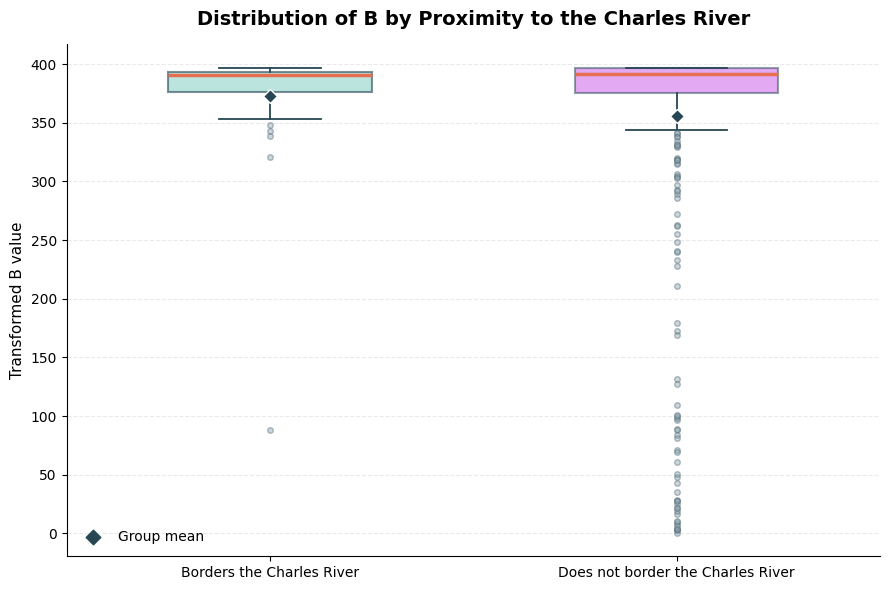

In [31]:
# the box plot visually compares the distributions of the two groups
fig, ax = plt.subplots(figsize=(9, 6))

box = ax.boxplot(
    [chas_1['B'].dropna(), chas_0['B'].dropna()],
    labels=[
        "Borders the Charles River",
        "Does not border the Charles River"
    ],
    patch_artist=True,
    widths=0.5,
    showmeans=True,
    boxprops={
        "edgecolor": "#264653",
        "linewidth": 1.5
    },
    medianprops={
        "color": "#E76F51",
        "linewidth": 2.5
    },
    meanprops={
        "marker": "D",
        "markerfacecolor": "#264653",
        "markeredgecolor": "white",
        "markersize": 7
    },
    whiskerprops={
        "color": "#264653",
        "linewidth": 1.3
    },
    capprops={
        "color": "#264653",
        "linewidth": 1.3
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": "#90A4AE",
        "markeredgecolor": "#546E7A",
        "markersize": 4,
        "alpha": 0.45
    }
)

# adding different colours to the two groups
# adding semi-transparent colours to the two groups
box["boxes"][0].set_facecolor("#8DD3C7")
box["boxes"][0].set_alpha(0.6)

box["boxes"][1].set_facecolor("#C955E9")
box["boxes"][1].set_alpha(0.5)

# adding a legend for the mean
ax.scatter(
    [],
    [],
    marker="D",
    color="#264653",
    s=55,
    label="Group mean"
)

ax.set_title(
    "Distribution of B by Proximity to the Charles River",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("")
ax.set_ylabel("Transformed B value", fontsize=11)

ax.grid(
    axis="y",
    color="#D9D9D9",
    linestyle="--",
    alpha=0.55
)

ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower left")
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The mean value of the transformed B indicator is slightly higher in areas bordering the Charles River (372.99) than in non-bordering areas. The box plot also shows that the CHAS = 0 group contains more outliers and greater dispersion, indicating stronger heterogeneity in the transformed indicator among areas that do not border the river. Nevertheless, the two-sample t-test shows that the difference is not statistically significant. Therefore, the observed difference between the group means may be attributable to random sampling variation.

The value 372.99 is not a percentage, so it should be described as the **transformed B indicator**, not as the proportion of African American residents.
